In [5]:
from utils import GCNmodel
from utils import RedditDataset

dataset = RedditDataset(path="Reddit")

batch_size = 2048
lr = 1e-4
num_epochs = 10

Numero di nodi:  232965
Numero di archi:  114615892
Dimensionalità delle features:  602
Di queste, le prime 300 l'embedding di Glove del titolo, le seconde 300 l'embedding di Glove medio di tutti i commenti
La feature 601 è lo score di reddit e la 602 è il numero di commenti
--------------------------------------------------------------------
Analisi della cardinalità delle classi e bilanciamento del dataset
classe  0 :  13101 -- 5.62%
classe  1 :   3550 -- 1.52%
classe  2 :   3302 -- 1.42%
classe  3 :  15181 -- 6.52%
classe  4 :   2322 -- 1.00%
classe  5 :   3597 -- 1.54%
classe  6 :   3952 -- 1.70%
classe  7 :   2138 -- 0.92%
classe  8 :  11187 -- 4.80%
classe  9 :   2246 -- 0.96%
classe 10 :   4928 -- 2.12%
classe 11 :   2964 -- 1.27%
classe 12 :   1696 -- 0.73%
classe 13 :   2731 -- 1.17%
classe 14 :   4854 -- 2.08%
classe 15 :  28272 -- 12.14%
classe 16 :   1003 -- 0.43%
classe 17 :   2639 -- 1.13%
classe 18 :  13999 -- 6.01%
classe 19 :  10308 -- 4.42%
classe 20 :   1596 -- 0.69%

VALUTAZIONE DELLA DENSITÀ LOCALE
Nodo Target Centrale analizzato: 3446
Cardinalità del sotto-grafo: 200 nodi
Numero di archi locali interni: 9479


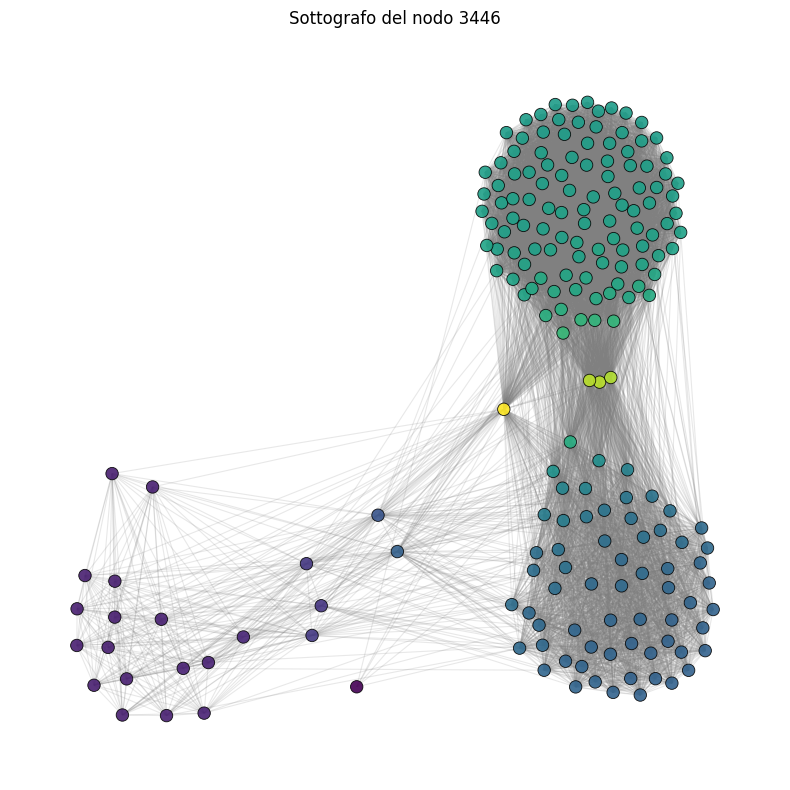

In [6]:
dataset.visualize(max_nodes=200)

In [7]:
train_loader, val_loader, test_loader = dataset.get_node_loaders(batch_size=batch_size)

In [8]:
import torch
from sklearn.metrics import f1_score, classification_report
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Inizio Task 1 su dispositivo: {device}")

data = dataset.dataset
stats = dataset.stats
patience = 5
patience_counter = 0
best_val_loss = float('inf')
best_model_path = 'best_model.pth'

labels_train = data.y[data.train_mask]
conteggi = torch.bincount(labels_train)
pesi_classi = 1.0 / (conteggi.float() + 1e-6)
pesi_classi = pesi_classi / pesi_classi.sum()
pesi_classi = pesi_classi.to(device)

model = GCNmodel(
    in_channels=stats.num_features,
    hidden_size=256,
    out_channels=len(stats.classes)
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss(weight=pesi_classi)
scaler = torch.cuda.amp.GradScaler()

def train_epoch(epoch_idx):
    model.train()
    total_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoca {epoch_idx:02d} [Train AMP]", leave=False)
    for batch in pbar:
        batch = batch.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            out = model(batch.x, batch.edge_index)
            loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * batch.batch_size
        pbar.set_postfix({"loss_batch": f"{loss.item():.4f}"})

    return total_loss / stats.train_size

@torch.no_grad()
def evaluate(loader, desc="Valutazione"):
    model.eval()
    all_preds = []
    all_targets = []
    total_loss = 0.0
    total_samples = 0

    for batch in tqdm(loader, desc=desc, leave=False):
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)

        loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])
        total_loss += loss.item() * batch.batch_size
        total_samples += batch.batch_size

        preds = out[:batch.batch_size].argmax(dim=-1)
        targets = batch.y[:batch.batch_size]

        all_preds.append(preds.cpu())
        all_targets.append(targets.cpu())

    y_pred = torch.cat(all_preds, dim=0).numpy()
    y_true = torch.cat(all_targets, dim=0).numpy()

    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_micro = f1_score(y_true, y_pred, average='micro')
    avg_loss = total_loss / total_samples

    return f1_macro, f1_micro, y_true, y_pred, avg_loss

# ====================================================================
# LOOP DI ADDESTRAMENTO PRINCIPALE
# ====================================================================
print("\n--- AVVIO LOOP DI ADDESTRAMENTO ---")
for epoch in range(1, num_epochs + 1):
    loss_corrente = train_epoch(epoch)
    val_macro, val_micro, _, _, val_loss = evaluate(val_loader, desc=f"Epoca {epoch:02d} [Val]")

    print(f"Epoca: {epoch:02d}/{num_epochs:02d} | "
          f"Loss Train: {loss_corrente:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Micro: {val_micro:.4f} | "
          f"Val F1-Macro: {val_macro:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  → Nuovo best model salvato (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  → No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"\nEarly stopping attivato all'epoca {epoch}.")
            break
    # ----------------------------------------------------------------

# ====================================================================
# VALUTAZIONE FINALE SUL TEST SET
# ====================================================================
print("\n--- CARICAMENTO MIGLIOR MODELLO PER IL TEST ---")
model.load_state_dict(torch.load(best_model_path))

print("\n--- VERIFICA METRICHE FINALI SUL TEST SET ---")
test_macro, test_micro, y_true, y_pred, _ = evaluate(test_loader, desc="Test Finale")

print(f"\n[RISULTATI GLOBALI TASK 1]")
print(f"Accuracy Globale (F1-Micro): {test_micro:.4f}")
print(f"Bilanciamento Classi (F1-Macro): {test_macro:.4f}\n")

print("Report analitico per singola categoria di subreddit:")
print(classification_report(y_true, y_pred, zero_division=0))

C:\Users\giaco\AppData\Local\Temp\ipykernel_15768\1887575229.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Inizio Task 1 su dispositivo: cuda

--- AVVIO LOOP DI ADDESTRAMENTO ---


Epoca: 01/10 | Loss Train: 3.3697 | Val F1-Micro: 0.4998 | Val F1-Macro: 0.3732


Epoca: 02/10 | Loss Train: 2.4493 | Val F1-Micro: 0.8353 | Val F1-Macro: 0.6981


Epoca: 03/10 | Loss Train: 1.7008 | Val F1-Micro: 0.8902 | Val F1-Macro: 0.8133


...

Epoca: 07/10 | Loss Train: 0.8486 | Val F1-Micro: 0.9161 | Val F1-Macro: 0.8553


Epoca: 08/10 | Loss Train: 0.7917 | Val F1-Micro: 0.9169 | Val F1-Macro: 0.8564


Epoca: 09/10 | Loss Train: 0.7558 | Val F1-Micro: 0.9165 | Val F1-Macro: 0.8585


Epoca: 10/10 | Loss Train: 0.7246 | Val F1-Micro: 0.9201 | Val F1-Macro: 0.8633

--- VERIFICA METRICHE FINALI SUL TEST SET ---



[RISULTATI GLOBALI TASK 1]
Accuracy Globale (F1-Micro): 0.9186
Bilanciamento Classi (F1-Macro): 0.8633

Report analitico per singola categoria di subreddit:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96      3207
           1       0.96      0.98      0.97       857
           2       0.91      0.88      0.89       743
           3       0.98      0.99      0.99      3200
           4       0.75      0.82      0.78       525
           5       0.92      0.97      0.94       855
           6       0.91      0.94      0.93       799
           7       0.77      0.93      0.84       464
           8       0.96      0.97      0.97      2517
           9       0.92      0.95      0.94       553
          10       0.95      0.94      0.95      1072
          11       0.97      1.00      0.98       657
          12       0.77      0.99      0.86       404
          13       0.59      0.55      0.57       597
          14       0.95      0.

In [9]:
from sklearn.metrics import balanced_accuracy_score


print(balanced_accuracy_score(y_true, y_pred))

0.8800386388300488


In [12]:
print(next(iter(train_loader)).x.shape)

torch.Size([138855, 602])
